# (A) Identification of Candidate Datasets

1. FOODPUZZLE
- Dataset name and source
  - Name: FoodPuzzle (a benchmark dataset for flavor science)
  - Primary source: built by crawling FlavorDB (Cosylab / IIIT-Delhi) and restructuring it into FoodPuzzle’s format.
- Course topic alignment
  - Frequent itemsets and association rules: treat each food as a “basket/transaction” of molecules (items). Variable-length baskets are natural here.
  - Clustering / dimensionality reduction (exploratory mining): foods can be encoded as a 1766-dimensional vector and clustered (they even show PCA clustering patterns).
- Potential beyond-course techniques
  - Multi-label learning: each food maps to a set of molecules (not a single label).
  - Representation learning (embeddings): learn molecule/food embeddings from the bipartite structure (e.g., node2vec-style, GNNs).
- Dataset size and structure
  - Core scale: 978 foods mapped to 1,766 flavor molecules. Each food has a variable-size set of associated molecules; most foods have relatively few, while a smaller number have many. Foods can be represented as a 978 × 1766 sparse/binary matrix (or per-food 1766-D vector).

  - How it’s organized (from the paper’s construction description):

    - Store 1: molecule profile info (properties + flavor characteristics)

    - Store 2: food item info (type/category + molecular composition)

    - Store 3: an association matrix as (food_id, molecule_id) pairs
  - train/dev/test split used for their baseline work: 80/10/10.
- Data types
  - Food identifiers / names, plus macro category labels (21 categories).
  - Molecule identifiers / names, plus molecule properties (example given: isotope atom count) and sensory descriptors (example given: odor).
  - Edges/associations: pairs of (food_id, molecule_id).
  - Repo also shows “task-style” JSON records for their benchmark tasks
- Target variable(s)
  - Unsupervised mining (classic association rules): no target variable
  - Supervised task (MFP): food macro-category (21 classes) as the target.
  - Completion task:missing molecules (set prediction / multi-label).
- Licensing or usage constraints
  - Upstream data (FlavorDB): FlavorDB’s site states it is licensed CC BY-NC-SA 3.0
  - Repo license: the GitHub repo indicates MIT (at least for the project code).


2. Yambda
- Dataset name and source
  - Name: Yambda-5B — A Large-Scale Multi-modal Dataset for Ranking And Retrieval
  - Source: interaction logs from the Yandex.Music streaming platform (anonymized)
- Course topic alignment
  - Sequential / temporal mining (per-user time-ordered histories; timestamps are present).
  - clustering
- Potential beyond-course techniques
  - Recommender systems / collaborative filtering on implicit + explicit feedback (listens + likes/dislikes/unlikes/undislikes).
  - Ranking
  - Transformer-based sequential recommendation (next-item prediction / session modeling) and large-scale ranking
- Dataset size and structure
  - Full scale (Yambda-5B): 1,000,000 users, 9,390,623 items (tracks), 4,649,567,411 listens, 89,334,605 likes, 11,579,143 dislikes.
  - Variants: 500M and 50M versions created by random user subsampling (1/10 and 1/100).
  - Storage: Parquet, with (a) flat tables per event type, (b) sequential per-user histories, plus a combined multi_event file.
- Data types
  - Core event fields: uid, item_id, timestamp, is_organic
  - Listen-specific fields: played_ratio_pct, track_length_seconds (present for listens and the combined multi-event table)
  - Side tables:artist–item mapping, album–item mapping,audio embeddings.parquet with embed and normalized_embed
  - Timestamps are transformed/rounded to preserve order at 5-second precision (and track length is rounded similarly).
- Target variable(s), if any – Next-item prediction
- Licensing or usage constraints: Apache-2.0

3. ViClaim
- Dataset name and source
  - ViClaim: A Multilingual Multilabel Dataset for Automatic Claim Detection in Videos
  - Source: YouTube Shorts (short-form YouTube videos, transcripts used for modeling). The authors release video IDs + sentence timestamps + labels, plus code to reconstruct transcripts rather than redistributing video/audio.
- Course topic alignment
  - Text embeddings
  - Clustering
  - Anomaly detection
- Potential beyond-course techniques
  - Multilingual transformer fine-tuning
  - Domain/topic transfer & domain adaptation (they explicitly “leave-topic-out” generalization).
- Dataset size and structure
  - 1,798 videos (short-form), 3 languages (EN/DE/ES), 6 topics.
  - 17,116 sentences total; transcripts are segmented into sentences and labeled at the sentence level.
  - 4 annotators per sentence (then aggregated; they also describe producing soft labels).
  - Structure is naturally hierarchical: video → transcript → ordered sentences, each with timestamps + labels.
- Data types
  - Identifiers: YouTube video ID
  - Temporal fields: sentence start/end timestamps (seconds)
  - Text: sentence text (reconstructed via pipeline); transcripts were originally produced with AssemblyAI and segmented with spaCy.
  - Categoricals: language (EN/DE/ES), topic (6 topics).
  - Labels: multi-label indicators (and potentially soft label probabilities if you generate/use them).
- Target variable(s), if any : None
- Licensing or usage constraints
  - The GitHub code repo indicates an MIT license.
  - A Zenodo dataset record for ViClaim lists CC BY 4.0.

# (B) Comparative Analysis of Datasets

### FoodPuzzle (food–molecule benchmark)

* **Supported data mining tasks (course → external)**

  * *Course:* Frequent itemset mining on “molecule baskets per food”; clustering foods by molecular vectors; basic bipartite graph mining.
  * *External:* Graph embeddings / link prediction on the food–molecule graph; “scientific agent” style retrieval/LLM-assisted hypothesis generation.
* **Data quality issues**

  * Coverage gaps and naming/normalization issues from sourcing (FlavorDB-derived); high-dim sparse vectors can amplify rare-item effects.
* **Algorithmic feasibility**

  * Very feasible on a single machine: ~978 foods (transactions) and 1,766 possible molecules → Apriori/FP-Growth and clustering are practical with reasonable support thresholds.
* **Bias considerations**

  * Coverage/curation bias: what’s “known and recorded” in the source database may overrepresent certain cuisines/ingredients and underrepresent others.
* **Ethical considerations**

  * Low direct human harm (not personal data). Potential downstream power imbalance: large firms could benefit more (product formulation), and results could be misinterpreted as health/chemistry claims without validation.

---

### Yambda (Yandex.Music large-scale recommendation logs)

* **Supported data mining tasks (course → external)**

  * *Course:* Graph mining on user–item bipartite graph; clustering users/items; anomaly detection (bots/fraud/unusual listening); sequence/session mining.
  * *External:* Deep recommenders (transformer/session models), graph neural recommenders, semantic IDs; audio-embedding–based retrieval (dataset includes audio embedding fields in some versions).
* **Data quality issues**

  * Implicit feedback noise (listen ≠ like), extreme sparsity/long-tail behavior; coarse time rounding (5s) can blur sessions.  
* **Algorithmic feasibility**

  * Full dataset is massive (4.79B events) → many “classic” algorithms aren’t feasible without sampling or distributed computing; they provide smaller variants (50M/500M) and Parquet for Spark/Hadoop pipelines.   
* **Bias considerations**

  * Recommendation feedback-loop bias is a core issue; dataset includes **is_organic** to distinguish organic actions vs recommender-driven ones.
  * Sampling bias toward active users (eligibility criteria require minimum activity).
* **Ethical considerations**

  * Privacy/profiling risk (listening histories can be sensitive). Power dynamic: platform/operator vs users; even with anonymization, aggregated behavior modeling can affect user autonomy (manipulation, targeting).

---

### ViClaim (YouTube Shorts STT transcripts + multilingual claim labels)

* **Supported data mining tasks (course → external)**

  * *Course:* Text mining (tokenization, features, classification basics); clustering by topic/stance; anomaly detection for unusual claim patterns.
  * *External:* Multilingual transformer fine-tuning; weak supervision / calibration; multimodal extensions (audio/video + text) for misinformation pipelines.
* **Data quality issues**

  * STT transcription noise (AssemblyAI) and sentence segmentation mismatch; labeling subjectivity (multi-label, nuanced taxonomy). They moved away from custom spans due to agreement issues.
* **Algorithmic feasibility**
  * Not a ready to use dataset, need a extra step to use code to get transcript.

  * Very feasible locally: ~1,798 videos / 17,116 sentences → classical NLP and transformer experiments are manageable on a single machine/GPU.
* **Bias considerations**

  * Topic selection + Western-world bias is explicitly noted; label distributions vary by topic (some topics have fewer check-worthy claims).  
* **Ethical considerations**

  * Misinformation labeling has dual use: helps fact-checking but can enable surveillance/over-moderation. Power dynamics: platforms/governments vs creators/viewers; political speech sensitivity is high.

# (C) Dataset Selection

Choice: **Yambda (Yandex.Music interaction logs)**

**Reasons**

* **Directly supports “course” large-scale data mining themes.** The dataset is built around *user–item interaction logs* at very large scale which naturally maps to **graph mining**, **clustering**, and **anomaly detection** in a realistic setting.
* **Lets me explicitly study recommendation feedback loops (a real-world bias issue).** Yambda includes an **is_organic** indicator to distinguish organic actions from recommender-driven ones, which makes it unusually good for analyzing **recommendation bias** and “closed-loop” dynamics.
* The dataset is distributed in **Parquet** and explicitly targets compatibility with **Spark/Hadoop**, plus it offers smaller dataset variants (e.g., **50M/500M**) so I can run experiments easily.

**Trade-offs (what you give up / must manage)**

* **Classic “transaction mining” is not the most natural fit at full scale.** Unlike retail baskets, events are sequential interactions; forcing Apriori-style baskets can be artificial, and on the full dataset it’s not computationally sensible without aggressive sampling/distribution. (I can still do basket-style analysis by sessionizing or time-windowing.)
* **High sparsity and long-tail effects complicate evaluation.** The dataset is designed around “extreme sparsity,” meaning many items/users have few interactions, which makes pattern mining and modeling harder and increases sensitivity to filtering choices.
* **Limited “ground-truth” labels for supervised learning.** Most signals are implicit feedback; strong supervised setups (like explicit class labels) are limited, so I need rely on ranking/next-item prediction evaluation rather than standard classification.
* **Privacy/ethics constraints are non-trivial.** Even anonymized listening logs are sensitive.
* **Sampling bias is baked in.** User inclusion criteria favor active users (minimum activity thresholds), which can skew findings toward heavy listeners.


# (D) Exploratory Data Analysis

This is a huge dataset. for initial EDA I only use a 50m parque of it.

## Overview, Schema + “valid ranges” sanity check

In [1]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_parquet("hf://datasets/yandex/yambda/flat/50m/multi_event.parquet")

In [2]:
df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,0,100.0,170.0,listen
1,100,39420,1441281,0,100.0,105.0,listen
2,100,39625,286361,0,100.0,185.0,listen
3,100,40110,732449,0,100.0,240.0,listen
4,100,40360,3397170,0,46.0,130.0,listen


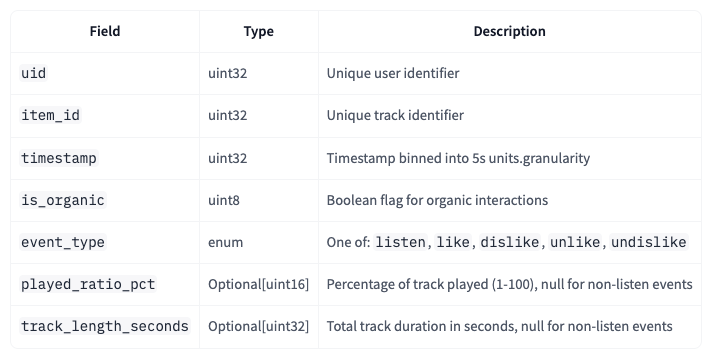

In [3]:
df.shape

(47790449, 7)

In [4]:
import numpy as np

# 1) column types
print(df.dtypes)

# 2) missingness
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing_rate"))

# 3) event types + organic share
display(df["event_type"].value_counts(dropna=False).head(20))
print("Organic share (mean of is_organic):", df["is_organic"].mean())

# 4) validity ranges
print("played_ratio_pct min/max:", df["played_ratio_pct"].min(), df["played_ratio_pct"].max())
print("track_length_seconds min/max:", df["track_length_seconds"].min(), df["track_length_seconds"].max())
print("timestamp min/max (5s bins):", df["timestamp"].min(), df["timestamp"].max())

# 5) duplicates (log-style definition)
dup_rate = df.duplicated(subset=["uid","timestamp","item_id","event_type"]).mean()
print("duplicate rate (uid,timestamp,item_id,event_type):", dup_rate)

uid                       uint32
timestamp                 uint32
item_id                   uint32
is_organic                 uint8
played_ratio_pct         float64
track_length_seconds     float64
event_type              category
dtype: object


,missing_rate
played_ratio_pct,0.027688
track_length_seconds,0.027688
uid,0.000000
item_id,0.000000
timestamp,0.000000
is_organic,0.000000
event_type,0.000000


,count
event_type,
listen,46467212
like,881456
unlike,312972
dislike,107776
undislike,21033


Organic share (mean of is_organic): 0.5205432575031885
played_ratio_pct min/max: 0.0 159.0
track_length_seconds min/max: 5.0 2495.0
timestamp min/max (5s bins): 0 26000000
duplicate rate (uid,timestamp,item_id,event_type): 0.012526373209006679


* Event types: mostly listen (46.5M), with smaller like/unlike/dislike/undislike.

* Missingness: ~2.77% missing in both played_ratio_pct and track_length_seconds (likely same rows).

* Organic share: ~52.05% organic.

* Data quality flags: played_ratio_pct max is 159 (invalid if it’s supposed to be 0–100), and duplicates ~1.25% by (uid,timestamp,item_id,event_type).

* **Time is measured as delta steps in 5-second bins, not absolute wall-clock time.**

In [5]:
import numpy as np

# 1) quantify missingness overlap
miss_play = df["played_ratio_pct"].isna()
miss_len  = df["track_length_seconds"].isna()
print("missing played_ratio_pct:", miss_play.mean())
print("missing track_length_seconds:", miss_len.mean())
print("missing both:", (miss_play & miss_len).mean())
print("missing only played:", (miss_play & ~miss_len).mean())
print("missing only length:", (~miss_play & miss_len).mean())

# 2) quantify invalid played_ratio_pct (only where non-missing)
nonmiss = df["played_ratio_pct"].notna()
invalid = nonmiss & ((df["played_ratio_pct"] < 0) | (df["played_ratio_pct"] > 100))
print("invalid played_ratio_pct rate (of all rows):", invalid.mean())
print("invalid played_ratio_pct rate (of non-missing):", (invalid.sum() / nonmiss.sum()))

# break invalid down by event_type (useful!)
invalid_by_type = df.loc[invalid, "event_type"].value_counts()
display(invalid_by_type)

# 3) create a clean analysis df for engagement metrics
clean = df.loc[nonmiss & df["track_length_seconds"].notna()].copy()

# keep invalid values for now but add a flag
clean["played_invalid"] = (clean["played_ratio_pct"] > 100) | (clean["played_ratio_pct"] < 0)

print("clean shape:", clean.shape)
print("clean invalid played_ratio_pct share:", clean["played_invalid"].mean())

missing played_ratio_pct: 0.027688314876472494
missing track_length_seconds: 0.027688314876472494
missing both: 0.027688314876472494
missing only played: 0.0
missing only length: 0.0
invalid played_ratio_pct rate (of all rows): 0.00456461499242244
invalid played_ratio_pct rate (of non-missing): 0.004694600571258719


,count
event_type,
listen,218145
dislike,0
like,0
undislike,0
unlike,0


clean shape: (46467212, 8)
clean invalid played_ratio_pct share: 0.004694600571258719


* Missingness is perfectly overlapping: the exact same 2.7688% of rows are missing both played_ratio_pct and track_length_seconds (so you can safely drop them for engagement analyses without introducing mismatched missingness).

* Invalid played_ratio_pct (>100) happens only for listen and is about 0.469% of non-missing rows.

In [6]:
# Unique counts
n_events = len(df)
n_users = df["uid"].nunique()
n_items = df["item_id"].nunique()
print("events:", n_events)
print("users:", n_users)
print("items:", n_items)
print("avg events/user:", n_events / n_users)
print("avg events/item:", n_events / n_items)

# Interactions per user / per item
user_counts = df.groupby("uid").size()
item_counts = df.groupby("item_id").size()

print("\nUser interactions percentiles:")
print(user_counts.quantile([0.5, 0.9, 0.95, 0.99]).to_string())

print("\nItem interactions percentiles:")
print(item_counts.quantile([0.5, 0.9, 0.95, 0.99]).to_string())

# Long-tail headline metrics (% items with <= k interactions)
for k in [1, 2, 5, 10]:
    print(f"% items with <= {k} interactions:", (item_counts <= k).mean())

# Popularity concentration (share of events accounted for by top items)
top100_share  = item_counts.sort_values(ascending=False).head(100).sum() / n_events
top1000_share = item_counts.sort_values(ascending=False).head(1000).sum() / n_events
print("\nTop-100 items share of all events:", top100_share)
print("Top-1000 items share of all events:", top1000_share)

events: 47790449
users: 10000
items: 934057
avg events/user: 4779.0449
avg events/item: 51.1643818310874

User interactions percentiles:
0.50     2653.50
0.90    12865.20
0.95    17092.95
0.99    24140.10

Item interactions percentiles:
0.50      3.0
0.90     58.0
0.95    159.0
0.99    945.0
% items with <= 1 interactions: 0.36365660768025937
% items with <= 2 interactions: 0.49041867894571745
% items with <= 5 interactions: 0.6416835375143058
% items with <= 10 interactions: 0.7372001922794862

Top-100 items share of all events: 0.0419215772590879
Top-1000 items share of all events: 0.17489107499282963


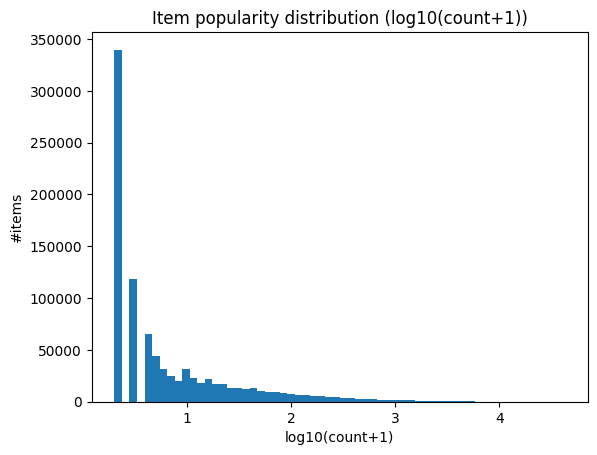

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.hist(np.log10(item_counts.values + 1), bins=60)
plt.title("Item popularity distribution (log10(count+1))")
plt.xlabel("log10(count+1)")
plt.ylabel("#items")
plt.show()


This dataset is extremely long-tail on items (median item has 3 interactions; 73.7% of items have ≤10 interactions), while users are relatively active (median user ~2,654 events). Perfect motivation for recommender methods.

## Organic vs non-organic(algorithmic) bias

*   List item
*   List item



In [8]:
mix = pd.crosstab(df["event_type"], df["is_organic"], normalize="columns")
counts = pd.crosstab(df["event_type"], df["is_organic"])
display(counts)
display(mix)

def topk_share(sub, k):
    c = sub.groupby("item_id").size().sort_values(ascending=False)
    return c.head(k).sum() / len(sub)

for flag in [0, 1]:
    sub = df[df["is_organic"] == flag]
    print(f"\n== is_organic={flag}  (n={len(sub):,}) ==")
    print("top-100 share:", topk_share(sub, 100))
    print("top-1000 share:", topk_share(sub, 1000))

clean_listen = clean[clean["event_type"] == "listen"].copy()

clean_listen["played_clip"] = clean_listen["played_ratio_pct"].clip(0, 100)

clean_listen["skip"] = clean_listen["played_clip"] < 20
clean_listen["full"] = clean_listen["played_clip"] >= 95

eng = clean_listen.groupby("is_organic").agg(
    n=("uid","size"),
    skip_rate=("skip","mean"),
    full_rate=("full","mean"),
    played_mean=("played_clip","mean"),
    len_mean=("track_length_seconds","mean"),
    invalid_played_share=("played_invalid","mean")
)
display(eng)


is_organic,0,1
event_type,,
listen,22463555,24003657
dislike,51788,55988
like,379255,502201
undislike,2324,18709
unlike,16531,296441


is_organic,0,1
event_type,,
listen,0.980365,0.964894
dislike,0.002260,0.002251
like,0.016552,0.020187
undislike,0.000101,0.000752
unlike,0.000721,0.011916



== is_organic=0  (n=22,913,453) ==
top-100 share: 0.034365619184502656
top-1000 share: 0.17237127027515234

== is_organic=1  (n=24,876,996) ==
top-100 share: 0.05467710008073322
top-1000 share: 0.19338195013578005


,n,skip_rate,full_rate,played_mean,len_mean,invalid_played_share
is_organic,,,,,,
0,22463555,0.260035,0.632087,69.577250,201.193635,0.002407
1,24003657,0.346471,0.518466,60.150256,213.230911,0.006836


* Event mix differs by organic: organic has a much higher unlike rate (1.19% vs 0.07%) and slightly higher like share too.

* Popularity concentration is higher for organic (top-100: 5.47% organic vs 3.44% non-organic; top-1000: 19.34% vs 17.24%).

* Engagement: organic listens have higher skip rate (34.6% vs 26.0%) and lower full-listen rate (51.8% vs 63.2%).

* Invalid played ratio is more common in organic listens (0.68% vs 0.24%).

## Sessionization + sequential behavior

A peer-reviewed Nature Scientific Reports paper on clickstream trajectories states: “the industry standard of 30 minutes is chosen as the session threshold” (new session if two events are >30 minutes apart). So I used the following standard to create sessions for users:
1. Sort events by user and time

2. Compute the time gap between consecutive events for the same user

3. Start a new session whenever the gap is greater than 30 minutes (1,800 seconds)

Gap (minutes) percentiles:
0.50      11.666667
0.90      34.583333
0.95     199.583333
0.99    6456.375000


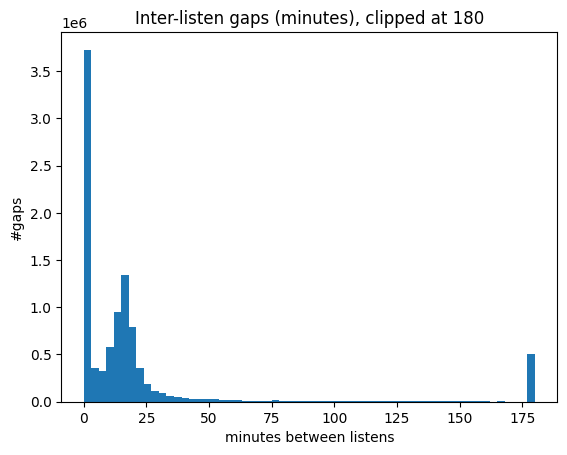

% gaps > 15 min: 0.37878029506484895
% gaps > 30 min: 0.11134961665552522
% gaps > 60 min: 0.07216772630109457


In [9]:
# To justify my choice of 30 minutes
d = df[["uid","timestamp"]].copy()
d["t_sec"] = d["timestamp"].astype("int64") * 5
d = d.sort_values(["uid","t_sec"])

# sample users for speed
sample_uids = np.random.choice(d["uid"].unique(), size=2000, replace=False)
ds = d[d["uid"].isin(sample_uids)].copy()

gaps = ds.groupby("uid")["t_sec"].diff().dropna()
gaps_min = gaps / 60

print("Gap (minutes) percentiles:")
print(gaps_min.quantile([0.5, 0.9, 0.95, 0.99]).to_string())

plt.figure()
plt.hist(gaps_min.clip(upper=180), bins=60)
plt.title("Inter-listen gaps (minutes), clipped at 180")
plt.xlabel("minutes between listens")
plt.ylabel("#gaps")
plt.show()

for thr in [15, 30, 60]:
    print(f"% gaps > {thr} min:", (gaps_min > thr).mean())


Session size percentiles:
0.50     4.0
0.90    21.0
0.95    33.0
0.99    74.0

Session duration (min) percentiles:
0.50     26.250000
0.90    193.750000
0.95    298.750000
0.99    679.166667


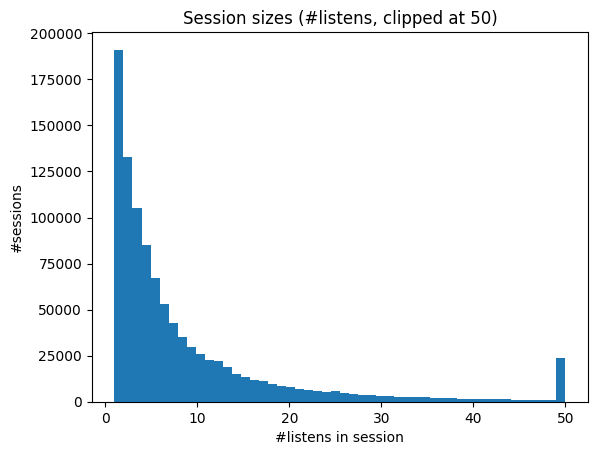

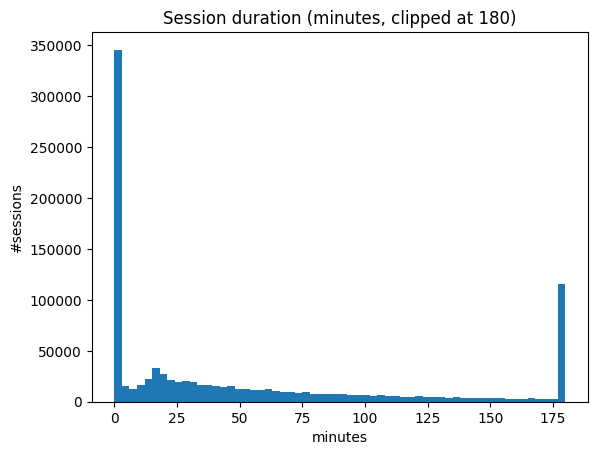


% sessions with a repeated track: 0.1860025834785269


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = df[["uid","timestamp","item_id","played_ratio_pct","is_organic", "event_type"]].copy()

# Convert delta bins -> seconds
d["t_sec"] = d["timestamp"].astype("int64") * 5
d = d.sort_values(["uid","t_sec"])

# Sample users (speed)
sample_uids = np.random.choice(d["uid"].unique(), size=2000, replace=False)
s = d[d["uid"].isin(sample_uids)].copy()

# Session break: gap > 30 min
gap = s.groupby("uid")["t_sec"].diff().fillna(0)
s["new_session"] = (gap > 1800).astype("int8")
s["session_id"] = s.groupby("uid")["new_session"].cumsum()

# Session size + duration
sess_sizes = s.groupby(["uid","session_id"]).size()
sess_dur = s.groupby(["uid","session_id"])["t_sec"].agg(lambda x: x.max() - x.min())

print("Session size percentiles:")
print(sess_sizes.quantile([0.5, 0.9, 0.95, 0.99]).to_string())
print("\nSession duration (min) percentiles:")
print((sess_dur/60).quantile([0.5, 0.9, 0.95, 0.99]).to_string())

# Plot distributions (clipped for readability)
plt.figure()
plt.hist(sess_sizes.clip(upper=50), bins=50)
plt.title("Session sizes (#listens, clipped at 50)")
plt.xlabel("#listens in session")
plt.ylabel("#sessions")
plt.show()

plt.figure()
plt.hist((sess_dur/60).clip(upper=180), bins=60)
plt.title("Session duration (minutes, clipped at 180)")
plt.xlabel("minutes")
plt.ylabel("#sessions")
plt.show()

# Simple sequential insight: repeat listening within session
repeat_rate = (
    s.groupby(["uid","session_id"])["item_id"]
     .apply(lambda x: x.duplicated().any())
     .mean()
)
print("\n% sessions with a repeated track:", repeat_rate)

In [11]:
# Session-level aggregates
sess = s.groupby(["uid","session_id"]).agg(
    n_listens=("item_id","size"),
    dur_min=("t_sec", lambda x: (x.max() - x.min())/60),
    organic_rate=("is_organic","mean"),
    n_unique_tracks=("item_id","nunique"),
)

# Label session by majority organic
sess["session_is_organic"] = (sess["organic_rate"] >= 0.5).astype(int)

# Add engagement if played_ratio exists (it does for listen rows; may include NaNs)
# We'll compute skip/full within session using the same heuristics, clipping invalids.
temp = s.copy()
temp["played_clip"] = temp["played_ratio_pct"].clip(0, 100)
temp["skip"] = temp["played_clip"] < 20
temp["full"] = temp["played_clip"] >= 95

sess_eng = temp.groupby(["uid","session_id"]).agg(
    skip_rate=("skip","mean"),
    full_rate=("full","mean"),
    played_mean=("played_clip","mean"),
)

sess = sess.join(sess_eng, on=["uid","session_id"])

# Summarize by session type
summary = sess.groupby("session_is_organic").agg(
    n_sessions=("n_listens","size"),
    n_listens_median=("n_listens","median"),
    n_listens_p90=("n_listens", lambda x: x.quantile(0.90)),
    dur_median=("dur_min","median"),
    dur_p90=("dur_min", lambda x: x.quantile(0.90)),
    unique_tracks_median=("n_unique_tracks","median"),
    skip_rate_mean=("skip_rate","mean"),
    full_rate_mean=("full_rate","mean"),
    played_mean=("played_mean","mean"),
)
display(summary)

# How mixed are sessions?
mix_stats = sess["organic_rate"].describe()
print("Session organic_rate summary:")
display(mix_stats)
print("% pure organic sessions:", (sess["organic_rate"] == 1.0).mean())
print("% pure non-organic sessions:", (sess["organic_rate"] == 0.0).mean())


,n_sessions,n_listens_median,n_listens_p90,dur_median,dur_p90,unique_tracks_median,skip_rate_mean,full_rate_mean,played_mean
session_is_organic,,,,,,,,,
0,441717,5.0,24.0,37.916667,242.916667,5.0,0.171219,0.684270,77.125812
1,574742,4.0,19.0,19.166667,157.083333,4.0,0.230622,0.561881,69.004943


Session organic_rate summary:


,organic_rate
count,1.016459e+06
mean,5.611583e-01
std,4.767934e-01
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


% pure organic sessions: 0.5073032950665005
% pure non-organic sessions: 0.37778601989849075


* Most visits are short (a handful of actions)

* A non-trivial minority are long “listening/browsing streaks” (heavy tail)

* Sessions aren’t purely “new-item exploration”, there’s meaningful repetition.

## event-type transition probabilities

In [13]:
# 0) Ensure ordering
seq = s[["uid","session_id","t_sec","event_type","is_organic"]].copy()
seq = seq.sort_values(["uid","session_id","t_sec"])

# 1) Build next-event transitions within each session ---
seq["next_event"] = seq.groupby(["uid","session_id"])["event_type"].shift(-1)
trans = seq.dropna(subset=["next_event"]).copy()

# Count transitions
T = trans.groupby(["event_type","next_event"]).size().rename("n").reset_index()

# Transition probabilities P(next | current)
row_totals = T.groupby("event_type")["n"].transform("sum")
T["p_next_given_curr"] = T["n"] / row_totals

# Pivot to matrix (counts + probs)
T_mat_p = T.pivot(index="event_type", columns="next_event", values="p_next_given_curr").fillna(0)
T_mat_n = T.pivot(index="event_type", columns="next_event", values="n").fillna(0).astype(int)

print("Transition probability matrix P(next | current):")
display(T_mat_p)
print("Transition counts matrix:")
display(T_mat_n)

# Most common next action after LISTEN
listen_next = T[T["event_type"] == "listen"].sort_values("p_next_given_curr", ascending=False)
print("Most common next actions after LISTEN:")
display(listen_next[["next_event","n","p_next_given_curr"]].head(10))

# Q2: How often do we see LIKE -> UNLIKE within the same session? ---
# (a) immediate transition rate P(unlike | like)
like_row = T[(T["event_type"]=="like") & (T["next_event"]=="unlike")]
p_unlike_given_like = float(like_row["p_next_given_curr"]) if len(like_row) else 0.0
n_like_unlike = int(like_row["n"]) if len(like_row) else 0
print(f"Immediate LIKE→UNLIKE transitions: n={n_like_unlike},  P(unlike|like)={p_unlike_given_like:.6f}")

# (b) session-level prevalence: % sessions that contain at least one LIKE→UNLIKE transition anywhere
sess_has_like_unlike = (
    trans.assign(is_like_unlike=(trans["event_type"].eq("like") & trans["next_event"].eq("unlike")))
         .groupby(["uid","session_id"])["is_like_unlike"].any()
)
print("% sessions containing at least one immediate LIKE→UNLIKE:", sess_has_like_unlike.mean())

# Do transitions differ by organic-majority vs non-organic-majority sessions? ---
# Label sessions by majority organic
sess_org_rate = seq.groupby(["uid","session_id"])["is_organic"].mean()
sess_label = (sess_org_rate >= 0.5).astype(int).rename("session_is_organic")
trans2 = trans.join(sess_label, on=["uid","session_id"])

def transition_table(sub_trans):
    tmp = (sub_trans.groupby(["event_type","next_event"], observed=True)
                    .size().rename("n").reset_index())
    tmp["p"] = tmp["n"] / tmp.groupby("event_type")["n"].transform("sum")
    return tmp

T0 = transition_table(trans2[trans2["session_is_organic"] == 0])  # non-organic-majority
T1 = transition_table(trans2[trans2["session_is_organic"] == 1])  # organic-majority

cmp = pd.merge(T1, T0, on=["event_type","next_event"], how="outer", suffixes=("_org","_non"))

# Only fill numeric cols (avoid categorical fill issue)
for c in ["n_org","p_org","n_non","p_non"]:
    cmp[c] = cmp[c].fillna(0)

cmp["delta_p"] = cmp["p_org"] - cmp["p_non"]

display(cmp.sort_values("delta_p", ascending=False).head(15)[
    ["event_type","next_event","n_org","p_org","n_non","p_non","delta_p"]
])

display(cmp[cmp["event_type"]=="listen"].sort_values("delta_p", ascending=False).head(10)[
    ["event_type","next_event","n_org","p_org","n_non","p_non","delta_p"]
])


/tmp/ipython-input-3525283677.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  T = trans.groupby(["event_type","next_event"]).size().rename("n").reset_index()


Transition probability matrix P(next | current):


/tmp/ipython-input-3525283677.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  row_totals = T.groupby("event_type")["n"].transform("sum")


next_event,listen,dislike,like,undislike,unlike
event_type,,,,,
listen,0.987313,0.001080,0.010681,0.000028,0.000898
dislike,0.422315,0.402901,0.089848,0.022130,0.062807
like,0.586744,0.001486,0.368931,0.004213,0.038626
undislike,0.223645,0.009232,0.015485,0.682847,0.068791
unlike,0.201783,0.002254,0.016285,0.000252,0.779425


Transition counts matrix:


...

/tmp/ipython-input-3525283677.py:33: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_unlike_given_like = float(like_row["p_next_given_curr"]) if len(like_row) else 0.0
/tmp/ipython-input-3525283677.py:34: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  n_like_unlike = int(like_row["n"]) if len(like_row) else 0


Immediate LIKE→UNLIKE transitions: n=5693,  P(unlike|like)=0.038626
% sessions containing at least one immediate LIKE→UNLIKE: 0.006198327081697731


/tmp/ipython-input-3525283677.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp["p"] = tmp["n"] / tmp.groupby("event_type")["n"].transform("sum")
/tmp/ipython-input-3525283677.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp["p"] = tmp["n"] / tmp.groupby("event_type")["n"].transform("sum")


,event_type,next_event,n_org,p_org,n_non,p_non,delta_p
12,like,like,34650,0.478776,19726,0.262957,0.215819
24,unlike,unlike,41424,0.806683,4905,0.606379,0.200304
6,dislike,dislike,4285,0.493777,2688,0.311508,0.182270
18,undislike,undislike,1835,0.707675,458,0.598693,0.108982
9,dislike,unlike,929,0.107052,158,0.018310,0.088742
19,undislike,unlike,196,0.075588,35,0.045752,0.029836
14,like,unlike,3766,0.052037,1927,0.025688,0.026349
8,dislike,undislike,265,0.030537,118,0.013675,0.016862
16,undislike,dislike,29,0.011184,2,0.002614,0.008570
0,listen,listen,4211154,0.989687,3990739,0.984821,0.004867


,event_type,next_event,n_org,p_org,n_non,p_non,delta_p
0,listen,listen,4211154,0.989687,3990739,0.984821,0.004867
4,listen,unlike,6215,0.001461,1246,0.000307,0.001153
3,listen,undislike,169,0.000040,64,0.000016,0.000024
1,listen,dislike,3157,0.000742,5812,0.001434,-0.000692
2,listen,like,34340,0.008070,54388,0.013422,-0.005351


* Within sessionized event sequences, the most common transition after a listen is another listen (P≈0.987).

* Among feedback dynamics, like→unlike occurs with P(unlike|like)≈0.0386 and appears in about 0.62% of sessions at least once.

* Splitting sessions by majority is_organic reveals systematic differences: Algo-majority sessions have higher immediate listen→like (0.0134 vs 0.0081) and listen→dislike (0.00143 vs 0.000742) transitions, while organic-majority sessions have slightly higher listen→listen continuity and higher listen→unlike transitions.

## Item-level sequentiality

In [14]:
import pandas as pd
import numpy as np

seq = s[["uid","session_id","t_sec","item_id","event_type","is_organic"]].copy()
seq = seq.sort_values(["uid","session_id","t_sec"])

# restrict repetition analysis to listens only (most meaningful for "replay")
seq_listen = seq[seq["event_type"] == "listen"].copy()

# Label sessions by majority organic (based on ALL events in the session, not just listens)
sess_org_rate = seq.groupby(["uid","session_id"])["is_organic"].mean()
sess_label = (sess_org_rate >= 0.5).astype(int).rename("session_is_organic")

# Session-level repetition metrics
g = seq_listen.groupby(["uid","session_id"])

sess_stats = g.agg(
    n_listens=("item_id","size"),
    n_unique_tracks=("item_id","nunique")
)
sess_stats = sess_stats.join(sess_label, on=["uid","session_id"])

# Derived repetition metrics
sess_stats["has_repeat"] = sess_stats["n_unique_tracks"] < sess_stats["n_listens"]
sess_stats["repeat_events"] = sess_stats["n_listens"] - sess_stats["n_unique_tracks"]
sess_stats["repeat_event_rate"] = np.where(
    sess_stats["n_listens"] > 0,
    sess_stats["repeat_events"] / sess_stats["n_listens"],
    np.nan
)

# Overall metrics
print("Overall (listen events within session):")
print("  % sessions with >=1 repeated track:", sess_stats["has_repeat"].mean())
print("  mean repeat_event_rate:", sess_stats["repeat_event_rate"].mean())
print("  median repeat_event_rate:", sess_stats["repeat_event_rate"].median())

# Split by session type
summary = sess_stats.groupby("session_is_organic").agg(
    n_sessions=("has_repeat","size"),
    pct_sessions_with_repeat=("has_repeat","mean"),
    mean_repeat_event_rate=("repeat_event_rate","mean"),
    median_repeat_event_rate=("repeat_event_rate","median"),
    listens_median=("n_listens","median"),
    unique_tracks_median=("n_unique_tracks","median")
)
display(summary)

# Extra: where do repeats concentrate? (look at top repeated items overall)
# Count repeat occurrences within sessions by item
seq_listen["prev_item"] = seq_listen.groupby(["uid","session_id"])["item_id"].shift(1)
seq_listen["is_immediate_repeat"] = (seq_listen["item_id"] == seq_listen["prev_item"])

immediate_repeat_rate = seq_listen["is_immediate_repeat"].mean()
print("\nImmediate repeat rate (same track as previous listen in-session):", immediate_repeat_rate)

# Compare immediate repeat by session type
seq_listen = seq_listen.join(sess_label, on=["uid","session_id"])
imm_by_type = seq_listen.groupby("session_is_organic")["is_immediate_repeat"].mean()
print("\nImmediate repeat rate by session type:")
display(imm_by_type)


Overall (listen events within session):
  % sessions with >=1 repeated track: 0.15456039184948248
  mean repeat_event_rate: 0.03709557269334191
  median repeat_event_rate: 0.0


,n_sessions,pct_sessions_with_repeat,mean_repeat_event_rate,median_repeat_event_rate,listens_median,unique_tracks_median
session_is_organic,,,,,,
0,441077,0.080108,0.014345,0.0,5.0,5.0
1,552774,0.213968,0.055249,0.0,4.0,4.0



Immediate repeat rate (same track as previous listen in-session): 0.018146116173860166

Immediate repeat rate by session type:


,is_immediate_repeat
session_is_organic,
0,0.006814
1,0.028735


To quantify item-level sequentiality, we measured within-session track repetition using listen events.

* Overall, 15.46% of sessions contain at least one repeated track, with a mean repeat-event rate of 3.71% (median 0, indicating repeats are concentrated in a minority of sessions).

* Repetition differs sharply by session context: organic-majority sessions are 21.4% repeat-containing versus 8.0% for algorithmic-majority sessions, and their mean repeat-event rate is 5.52% vs 1.43%. Immediate repeats (same track as the previous listen) occur at 1.81% overall, but are ~4× higher in organic-majority sessions (2.87% vs 0.68%). These patterns suggest organic behavior includes more replay/return-to-item dynamics, while algorithmic sessions are more linear and exploration-oriented.

# (E) Initial Insights and Direction

* **Observation:** Item interactions are extremely long-tailed (median item has **3** interactions; **73.7%** of items have ≤ **10** interactions).
  
  **Hypothesis:** Popularity bias + sparsity will make naive popularity baselines strong, and mining needs careful thresholds/sampling.

* **Observation:** Data quality issues exist: **2.77%** rows missing both `played_ratio_pct` and `track_length_seconds`; **0.47%** of non-missing `played_ratio_pct` values exceed **100** (only in `listen`).
  
  **Hypothesis:** Engagement analyses should filter missing rows and clip/flag invalid played ratios to avoid biased skip/full rates.

* **Observation:** Organic vs algorithmic behavior differs strongly. Organic listens have **higher skip rate** (34.6% vs 26.0%) and **lower full-listen rate** (51.8% vs 63.2%).
  
  **Hypothesis:** Recommender-driven contexts may produce more “committed” listening, while organic behavior includes more quick sampling/skipping.

* **Observation:** Action dynamics are sequential but dominated by listening: `listen → listen` is **98.7%**; `listen → like` about **1.07%**.
  
  **Hypothesis:** Sequential models should focus on *within-session item sequences* rather than event-type sequences alone.

* **Observation:** Preference reversals exist but are rare: `P(unlike | like) ≈ 3.86%`, and only **0.62%** of sessions contain an immediate `like → unlike`.
  
  **Hypothesis:** “Library curation” happens, but most likes are stable within a session.

* **Observation:** Organic-majority sessions show more repetition: sessions with repeats are **21.4%** (organic) vs **8.0%** (algorithmic); immediate repeats are **2.87%** vs **0.68%**.
  
  **Hypothesis:** Organic sessions are more “replay/exploit,” while algorithmic sessions are more “explore/forward.”


## Potential research questions (RQs)

* **RQ1:** How do **organic vs algorithmic** sessions differ?
* **RQ2:** Do **sequential patterns** (within-session transitions / repeats) reveal structure missed by unordered “session baskets”?
* **RQ3:** How sensitive are findings to session definition (**15/30/60 min**) and engagement cleaning (drop-missing vs clip/flag invalid)?
* **RQ4:** Can we predict **next track** or **skip/full listen** better with sequential features than with popularity-only baselines, and does this differ by organic vs algorithmic context?


On my honor, I declare the following resources:
1. Collaborators:
- ...

2. Web Sources:
- https://huggingface.co/datasets/yandex/yambda?library=pandas
- https://www.nature.com/articles/s41598-020-73622-y?utm_source=chatgpt.com
- https://arxiv.org/abs/2504.12882
- https://github.com/tenghaohuang/FoodPuzzle/tree/main/data
3. AI Tools:
- ChatGPT: I gave it a snap shot of my raw table head, and asked it generate a code to sessionalize the dataset.  
- ...